Saving cardio_train.csv to cardio_train (3).csv
Dataset Loaded Successfully.

Columns: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Missing Values:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate Rows: 0

Data Preprocessing Completed.

Training Samples: 56000
Testing Samples: 14000


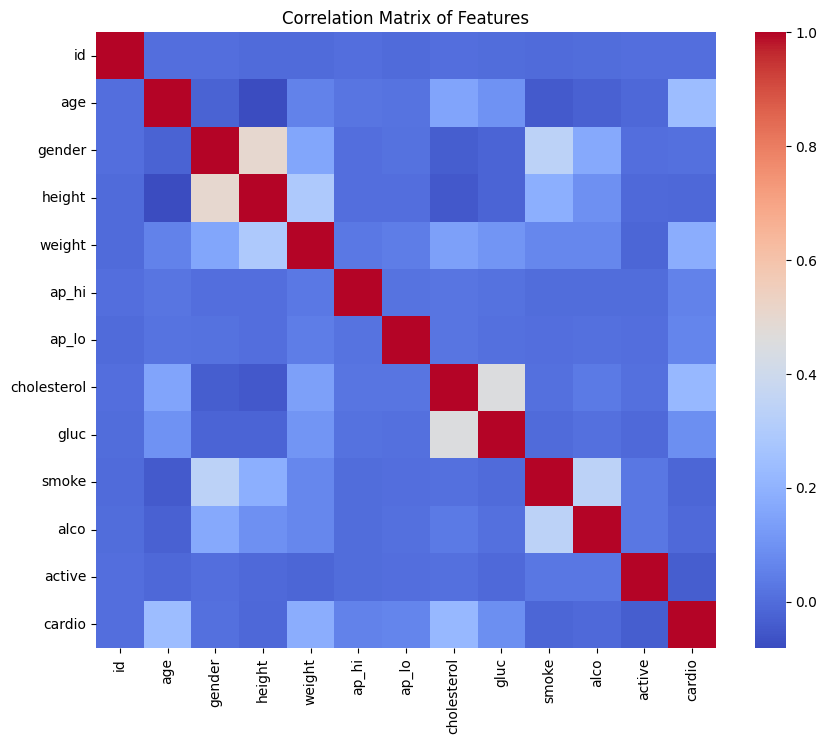

/tmp/ipython-input-2381912102.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=df, palette='viridis')


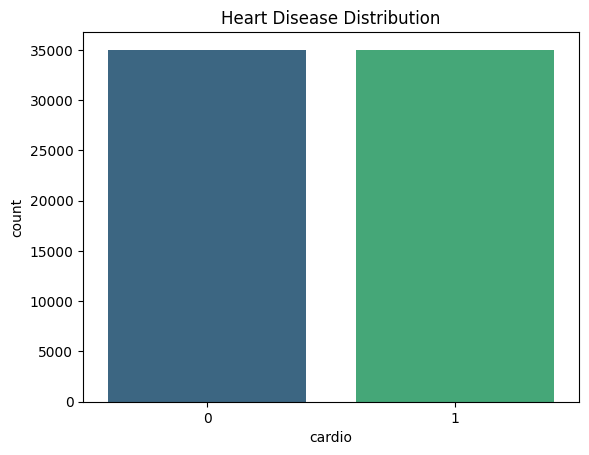

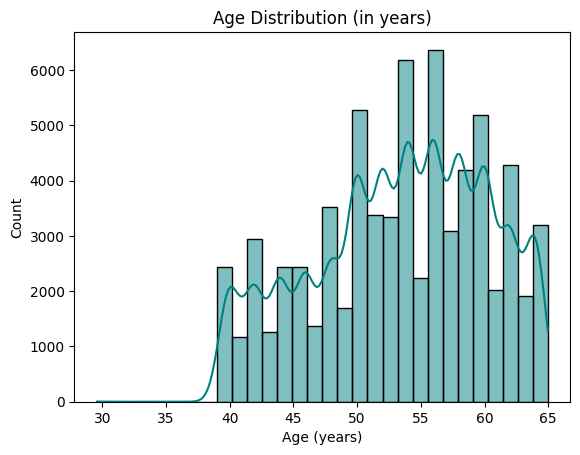

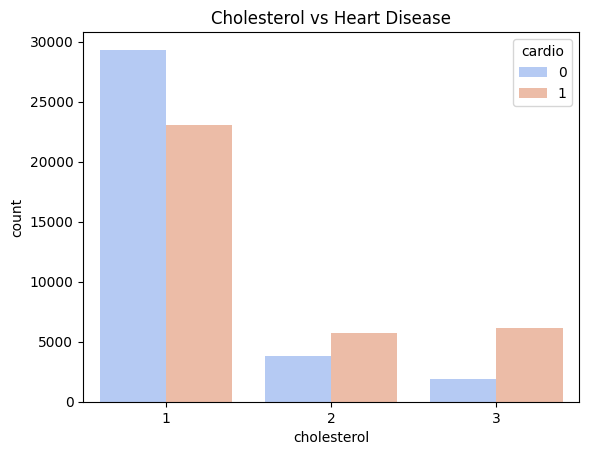


Training and Testing Models...

Support Vector Machine (linear): Accuracy = 0.7264
K-Nearest Neighbors: Accuracy = 0.6260
Decision Tree: Accuracy = 0.6346
Logistic Regression: Accuracy = 0.7233
Random Forest: Accuracy = 0.7277


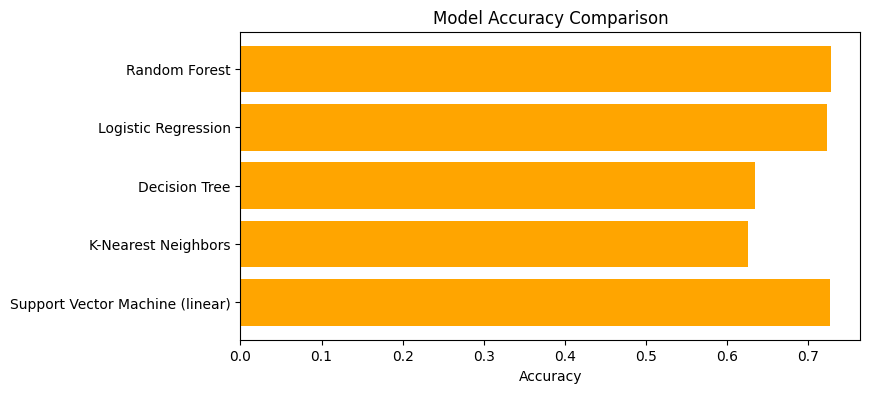


Best Model: Random Forest with Accuracy = 0.7277

Confusion Matrix:
 [[5255 1733]
 [2079 4933]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.75      0.73      6988
           1       0.74      0.70      0.72      7012

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000



In [ ]:
# Cardiovascular Disease Prediction – Minor Project
# Student: Kalyani Fulchandji Itankar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Step 1: Upload and Load the Dataset
from google.colab import files
uploaded = files.upload()  # Upload cardio_train.csv

# Important fix: dataset uses semicolons
df = pd.read_csv('cardio_train.csv', sep=';')
print("Dataset Loaded Successfully.\n")

# Step 2: Data Exploration
print("Columns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Step 3: Data Preprocessing
df = df.drop_duplicates()
X = df.drop('cardio', axis=1)
y = df['cardio']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nData Preprocessing Completed.\n")

# Step 4: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# Step 5: Visualizations
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

sns.countplot(x='cardio', data=df, palette='viridis')
plt.title('Heart Disease Distribution')
plt.show()

sns.histplot(df['age']/365, bins=30, kde=True, color='teal')
plt.title('Age Distribution (in years)')
plt.xlabel('Age (years)')
plt.show()

sns.countplot(x='cholesterol', hue='cardio', data=df, palette='coolwarm')
plt.title('Cholesterol vs Heart Disease')
plt.show()

# Step 6: Train and Evaluate Models
models = {
    'Support Vector Machine (linear)': SVC(kernel='linear'),  # faster than RBF
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier()
}

results = {}
print("\nTraining and Testing Models...\n")

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        print(f"{name}: Accuracy = {acc:.4f}")
    except Exception as e:
        print(f"{name} failed due to: {e}")

# Step 7: Compare Model Accuracies
plt.figure(figsize=(8,4))
plt.barh(list(results.keys()), list(results.values()), color='orange')
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

best_model_name = max(results, key=results.get)
print(f"\nBest Model: {best_model_name} with Accuracy = {results[best_model_name]:.4f}\n")

# Step 8: Evaluate Best Model
best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


